<h1><center>
King Faisal University <br>
College of Computer Sciences and Information Technology <br>
Data Science Course Project - CS412 – Academic Year 2023-2024, First Semester  <br> <br>
Submitted to : Ms.Nora Alshuaibi
   
  

    
</h1>

<h1><center>
                                  Predicting Income for Marketing  
    </h1>

## Team Members                               
 1. Aisha Abdurahman Almajed.                       
 2. Fatima yousef Alajwad .               
 3. Shahad Bu Saqer.
 4. Khulood Ghazi Almarri.

# Project Overview


## Problem Statement  
In today's data-driven business environment, understanding customer income levels and demographics is essential for effective marketing and business growth. Identifying high-income segments helps companies allocate resources efficiently and tailor customer engagement strategies. This project focuses on analyzing the Adult Income dataset to classify individuals into income categories (above or below $50,000) based on demographic and socioeconomic factors. By leveraging data science techniques, the goal is to uncover valuable insights that guide businesses in identifying high-income segments and optimizing their marketing strategies accordingly.


## Objectives  
1. To classify individuals' income levels using a predictive model based on demographic and    socioeconomic attributes.
2. To analyze patterns in the dataset, identifying key factors influencing income levels.
3. To derive actionable insights for customer segmentation that enable businesses to develop targeted marketing strategies.


## Dataset Description  


### Source  
The dataset used for this project is the **Adult Income dataset**, originally sourced from the UCI Machine Learning Repository. It was derived from the 1994 U.S. Census Bureau database and is widely used in data science for classification tasks. The dataset's significance lies in its rich combination of demographic and socioeconomic attributes, making it ideal for analyzing income levels and building predictive models for customer segmentation and marketing strategies.


### Size  
The dataset comprises:  
- **Rows (Instances)** 8428,756 records, each representing an individual.  
- **Columns (Attributes)**: 15 variables, including demographic features like age, education, and gender, socioeconomic features like occupation and hours worked per week, and a target variable (income) indicating whether an individual's income is <=50K or >50K.  
- **Variable Types**:  
  - **Categorical Variables**:  workclass, education, marital-status, occupation.  
  - **Numerical Variables**:  age, hours-per-week, capital-gain.  


### Challenges
Challenges include handling missing values, encoding categorical variables for classifying individuals into income categories (above or below $50,000) based on demographic and socioeconomic factors.Proper Preprocessing is critical to tackle these challenges, as it ensures the dataset is clean, appropriately structured, enabling the prediction model to deliver accurate and meaningful predictions of income categories.



# Import libraries

The following libraries and modules are imported to handle specific tasks:

1-pandas: Used for data manipulation and analysis, especially for handling tabular datasets.

2-numpy: Provides numerical computing functionality, including support for arrays and mathematical operations.

3-matplotlib.pyplot: Used for creating static, interactive, and animated visualizations.

4-scipy.stats: Includes statistical functions and is used here to create and interpret boxplots.

5-sklearn.preprocessing ( LabelEncoder, MinMaxScaler): Provides tools for data transformation, such as encoding categorical variables and scaling numerical data.

6-seaborn: Offers a high-level interface for creating attractive and informative statistical graphics.

7-sklearn.model_selection (train_test_split, GridSearchCV, cross_val_score): Provides tools for splitting datasets, performing hyperparameter tuning, and evaluating model performance.

8-sklearn.neighbors (KNeighborsClassifier): Implements the K-Nearest Neighbors algorithm for classification tasks.

9-sklearn.metrics: Contains methods for evaluating model performance, such as accuracy, precision, and recall.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#DT
from sklearn.tree import DecisionTreeClassifier
#NB
from sklearn.naive_bayes import GaussianNB
#RF
from sklearn.ensemble import RandomForestClassifier


# Load the adult income dataset

In [2]:
data = pd.read_csv("adult.csv")
data.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,205.0,Private,226802,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,NaN,0,0,40.0,United-States,<=50K
1,38.0,Private,89814,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,NaN,Male,0,0,NaN,NaN,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40.0,United-States,>50K
3,44.0,Private,160323,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,NaN,United-States,>50K
4,18.0,?,103497,Some-college,NaN,Never-married,?,Own-child,White,Female,0,0,30.0,United-States,<=50K
5,34.0,Private,198693,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0,0,30.0,United-States,<=50K
6,29.0,?,227026,HS-grad,9.0,Never-married,?,Unmarried,Black,NaN,0,0,40.0,NaN,<=50K
7,63.0,Self-emp-not-inc,104626,Prof-school,15.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32.0,United-States,>50K
8,24.0,Private,369667,Some-college,10.0,Never-married,Other-service,Unmarried,White,Female,0,0,NaN,United-States,<=50K
9,-55.0,Private,104996,7th-8th,4.0,Married-civ-spouse,Craft-repair,Husband,NaN,Male,0,0,10.0,United-States,<=50K


 #  Dataset Exploration and Preprocessing

## Data Exploration
- Review data types, unique values, and missing value patterns.
- Generated summary statistics to understand central tendencies and data spread.

In [3]:
# Dataset overview
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              48837 non-null  float64
 1   workclass        48840 non-null  object 
 2   fnlwgt           48842 non-null  int64  
 3   education        48842 non-null  object 
 4   educational-num  48839 non-null  float64
 5   marital-status   48839 non-null  object 
 6   occupation       48842 non-null  object 
 7   relationship     48840 non-null  object 
 8   race             48834 non-null  object 
 9   gender           48839 non-null  object 
 10  capital-gain     48842 non-null  int64  
 11  capital-loss     48842 non-null  int64  
 12  hours-per-week   48836 non-null  float64
 13  native-country   48836 non-null  object 
 14  income           48842 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 5.6+ MB


In [4]:
# Dataset overview
print("\nSummary Statistics:\n", data.describe())
print("\nMissing Values:\n", data.isnull().sum())
print("\nUnique Values per Column:\n", data.nunique())


Summary Statistics:
                 age        fnlwgt  educational-num  capital-gain  \
count  48837.000000  4.884200e+04     48839.000000  48842.000000   
mean      38.653664  1.896641e+05        10.077930   1079.067626   
std       13.886267  1.056040e+05         2.570921   7452.019058   
min      -55.000000  1.228500e+04         1.000000      0.000000   
25%       28.000000  1.175505e+05         9.000000      0.000000   
50%       37.000000  1.781445e+05        10.000000      0.000000   
75%       48.000000  2.376420e+05        12.000000      0.000000   
max      443.000000  1.490400e+06        16.000000  99999.000000   

       capital-loss  hours-per-week  
count  48842.000000    48836.000000  
mean      87.502314       40.418032  
std      403.004552       12.406123  
min        0.000000      -65.000000  
25%        0.000000       40.000000  
50%        0.000000       40.000000  
75%        0.000000       45.000000  
max     4356.000000       99.000000  

Missing Values:
 age  

## Data Cleaning



In [5]:

# Display the shape of the data before removing null values
print("Shape before removing null values:", data.shape)
# Remove rows with any null values
data = data.dropna()
# Display the shape of the data after removing null values
print("Shape after removing null values:", data.shape)


Shape before removing null values: (48842, 15)
Shape after removing null values: (48808, 15)


In [6]:

print("Shape before removing duplicates:", data.shape)

data.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", data.shape)

Shape before removing duplicates: (48808, 15)
Shape after removing duplicates: (48756, 15)


##  Handling Missing Values
Firstly,replacing ? with NaN, to become compatible with pandas' missing value handling functions. Then remove rows with missing values in specific columns to ensure data integrity.

In [7]:
data.isin(['?']).sum() # to see if ? is in the data

age                   0
workclass          2792
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2802
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      855
income                0
dtype: int64

In [8]:
print("Shape before handling missing values:", data.shape)
#replace each ? with NaN
data.replace("?", np.nan, inplace=True)
#delete all the NaN values
data.dropna(subset=['workclass', 'occupation', 'native-country'], inplace=True)

# Display the shape after handling missing values
print("Shape after handling missing values:", data.shape)

Shape before handling missing values: (48756, 15)
Shape after handling missing values: (45145, 15)


## Boxplot for Age and Outlier Removal
Create a boxplot for the 'age' to show how 'age' is distributed across the dataset and Identify the outliers. Negative values for age are nonsensical and could indicate data errors so we filter out negative values and zeros, then calculate Z-scores

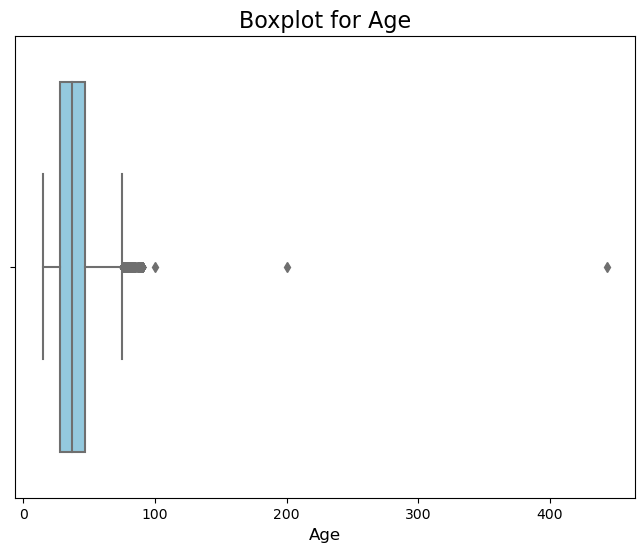

In [9]:

plt.figure(figsize=(8, 6))
sns.boxplot(data, x='age', color='skyblue')

# Add labels and title
plt.title('Boxplot for Age', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.show()


In [10]:
data = data[(data['age'] > 0)]


z_scores = np.abs(stats.zscore(data['age']))

#this threshold represent ages that are far beyond the reasonable range for human age.
#ensures that only data points with extremely unlikely ages are excluded
# minimizing the risk of removing valid but rare cases
outliers = data[z_scores > 5]
data_no_outliers = data[z_scores <= 5]

# Display results

print("Outliers based on Z-scores:")
print(outliers)
print('Shape befor removing outliers:', data.shape)
print('Shape after removing outliers:', data_no_outliers.shape)

Outliers based on Z-scores:
         age     workclass  fnlwgt  education  educational-num  \
17     443.0       Private  128354    HS-grad              9.0   
19529  200.0  Self-emp-inc  278322  Bachelors             13.0   

           marital-status    occupation relationship   race  gender  \
17     Married-civ-spouse  Adm-clerical         Wife  White  Female   
19529  Married-civ-spouse         Sales      Husband  White    Male   

       capital-gain  capital-loss  hours-per-week native-country income  
17                0             0            30.0  United-States  <=50K  
19529             0             0            45.0  United-States  <=50K  
Shape befor removing outliers: (45145, 15)
Shape after removing outliers: (45143, 15)


## Cleaning Categorical Data
 The unique values in the 'gender' and 'race' columns were checked to identify inconsistencies or unexpected categories.

In [11]:


data = data_no_outliers

print("Gender distribution:")
print(data["gender"].value_counts())
print()

print("Race distribution:")
print(data["race"].value_counts())
print()

# Define a function to clean gender and race data
def clean_categorical_data(df, column):
    # Check for unique values in the column
    unique_values = df[column].unique()
    print(f"Unique values in {column}: {unique_values}")

    if column == "gender":
        # Filter for only rows where the 'gender' column has values 'Male' or 'Female'
        df = df[df[column].isin(["Male", "Female"])]
    else:  # Assuming this is for the 'race' column
        # Retain rows where the column contains one of the expected racial categories
        df = df[
            df[column].isin(
                [
                    "White",
                    "Black",
                    "Asian-Pac-Islander",
                    "Amer-Indian-Eskimo",
                    "Other",
                ]
            )
        ]

    return df

# Clean 'gender' and 'race' columns
data_cleaned_gender = clean_categorical_data(data.copy(), "gender")  # Using a copy
data_cleaned_race = clean_categorical_data(data_cleaned_gender.copy(), "race")  # Using a copy

# Display shape of the data before and after cleaning
print("Shape before cleaning:", data.shape)
print("Shape after cleaning:", data_cleaned_race.shape)



Gender distribution:
gender
Male      30471
Female    14667
Z             3
S             2
Name: count, dtype: int64

Race distribution:
race
White                 38830
Black                  4222
Asian-Pac-Islander     1301
Amer-Indian-Eskimo      434
Other                   353
W                         3
Name: count, dtype: int64

Unique values in gender: ['Male' 'Female' 'S' 'Z']
Unique values in race: ['White' 'Black' 'Other' 'Amer-Indian-Eskimo' 'Asian-Pac-Islander' 'W']
Shape before cleaning: (45143, 15)
Shape after cleaning: (45135, 15)


## Income Analysis by Key Features


**pie chart**

shows the distribution of individuals in the data set by income group. It clearly shows the percentage of individuals who earn more than $50,000 a year (<=50K) compared to those who earn less (>50K).

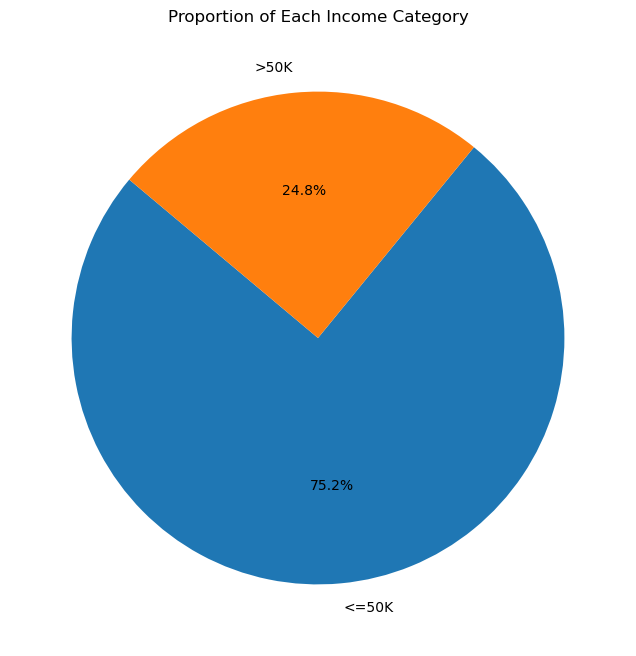

In [12]:

df = data_cleaned_race



workclass_counts = df['income'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(workclass_counts.values, labels=workclass_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Each Income Category')
plt.show()


**Grouped Bar Chart**

 shows the relationship between the level of education and the level of income. The number of individuals earning more than $50,000 per year (>50K) is compared to those earning less (<=50K) per level of education

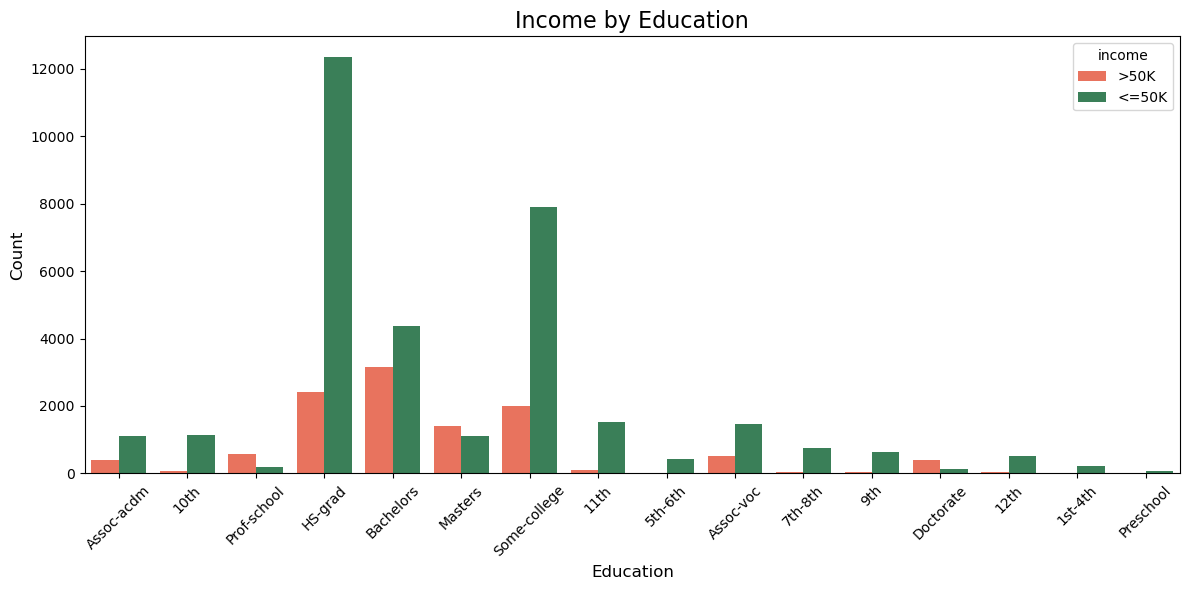

In [13]:

plt.figure(figsize=(12, 6))
sns.countplot(x='education', hue='income', data=df, palette=['#FF6347', '#2E8B57'])

plt.title('Income by Education', fontsize=16)
plt.xlabel('Education', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()






**Histogram chart**

This chart shows the age distribution of individuals in the data set, with them classified by income level (more than $50,000 or less). Helps us understand how ages are distributed in each income group

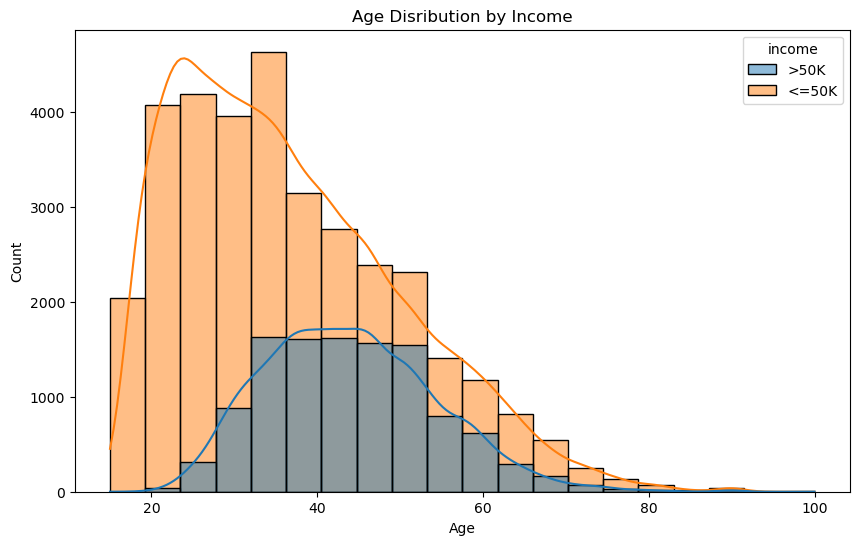

In [14]:

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='income', bins=20, kde=True)
plt.title('Age Disribution by Income')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Scatter Plot**

This chart shows the relationship between age and occupation, with individuals classified by income level (more than $50,000 or less)

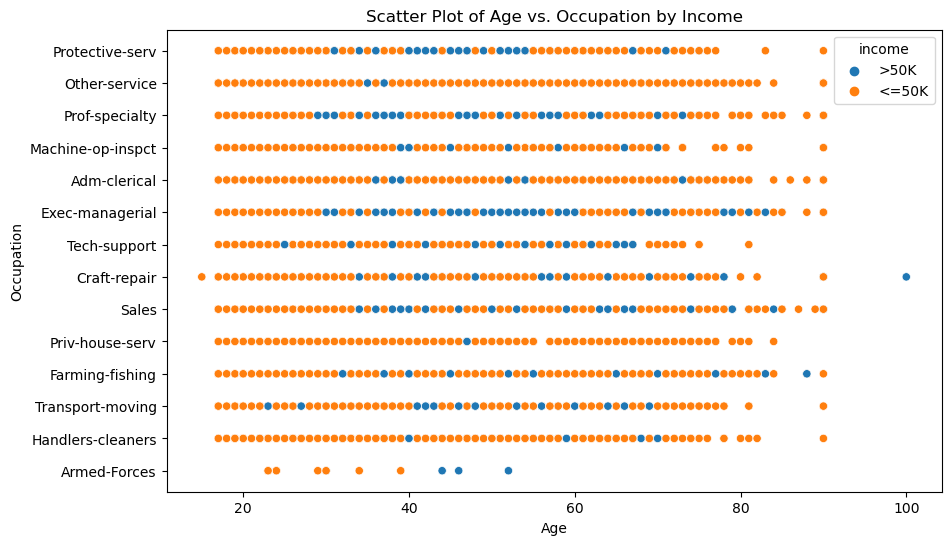

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='occupation', hue='income', data=df)
plt.title('Scatter Plot of Age vs. Occupation by Income')
plt.xlabel('Age')
plt.ylabel('Occupation')
plt.show()

## Dropping Irrelevant Columns
The 'education' and 'educational-num' columns likely contained overlapping information. So, we dropped educational-num to reduce redundancy without loss of information. Also, we dropped capital-gain and capital-loss because they are less relevant for the intended analysis

In [16]:

edu=df['education'].unique()
edu2=df['educational-num'].unique()
print("education",edu)
print('\n')
print("educational-num",edu2)



education ['Assoc-acdm' '10th' 'Prof-school' 'HS-grad' 'Bachelors' 'Masters'
 'Some-college' '11th' '5th-6th' 'Assoc-voc' '7th-8th' '9th' 'Doctorate'
 '12th' '1st-4th' 'Preschool']


educational-num [12.  6. 15.  9. 13. 14. 10.  7.  3. 11.  4.  5. 16.  8.  2.  1.]


- 'education': Contains string values representing the level of education (e.g., 'HS-grad', 'Masters', etc.).
- 'education-num': Contains numerical values that correspond to the education levels (e.g., 9 for 'HS-grad', 14 for 'Masters', etc.).
  
Both columns conveying same information
So, we can remove 'education-num's

Text(0.5, 1.0, 'Histogram')

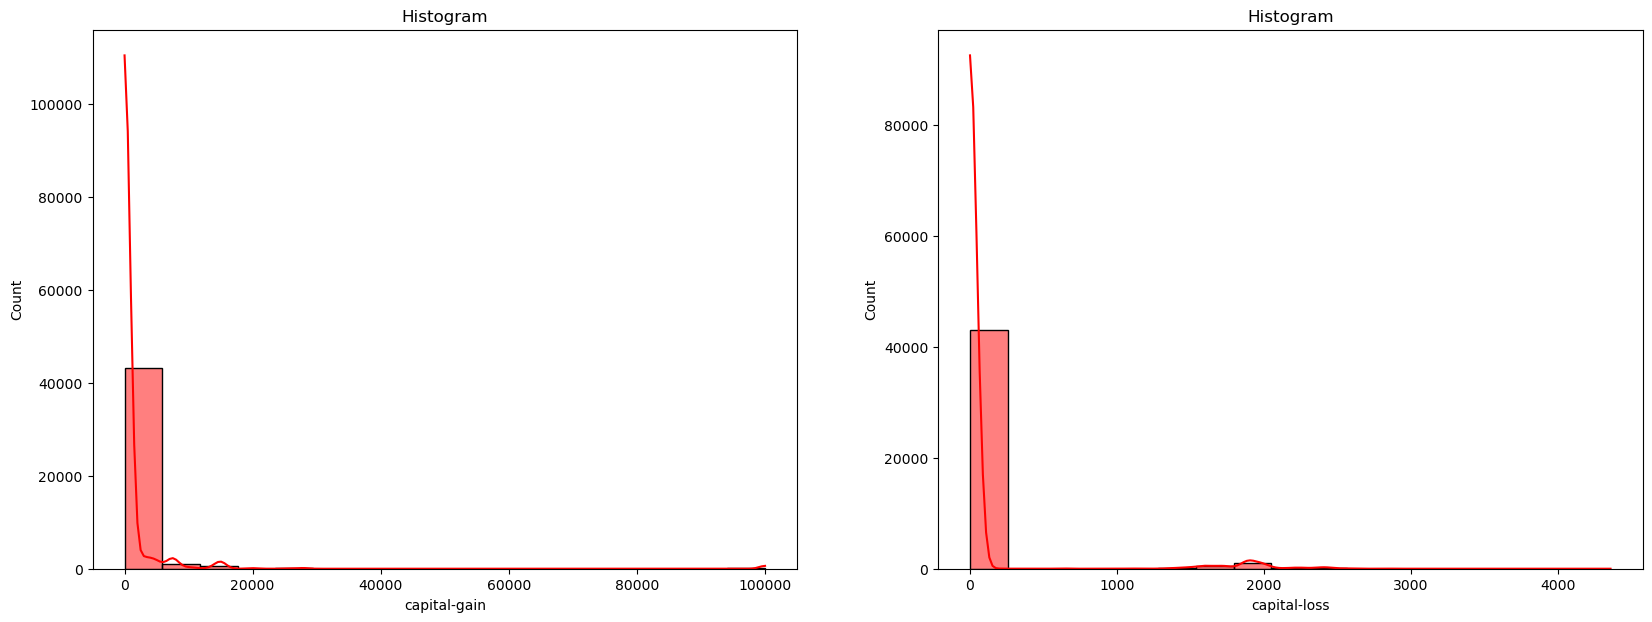

In [17]:
#Histograms helped visualize the distributions of capital-gain and capital-loss
#highlighting any skewness or unusual patterns in the data.
plt.figure(figsize=(20, 7))
plt.subplot(1, 2, 1)
sns.histplot(df['capital-gain'], kde = True,color='r')
plt.title('Histogram')
plt.subplot(1, 2, 2)
sns.histplot(df['capital-loss'], kde = True,color='r')
plt.title('Histogram')

[ 'capital-gain' ] & [ 'capital-loss' ] both columns have 75% data as 0.00 so, we can drop [ 'capital-gain' ] & [ 'capital-loss' ] both column

In [18]:

df = df.drop(['educational-num', 'capital-gain', 'capital-loss'], axis=1)

## Label Encoding for Categorical Features
Machine learning models generally require numerical input. Label encoding was used to convert categorical data into numerical format. Features like 'workclass', 'education', and 'income' were label-encoded. Encoding transformed them into integer representations, allowing them to be used as inputs for machine learning models.

In [19]:

# Label Encoding for categorical features
label_encoder = LabelEncoder()
categorical_columns = ['workclass', 'education', 'marital-status',
                       'occupation', 'relationship', 'race',
                       'gender', 'native-country', 'income']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])



# Display the updated DataFrame
df.head(10)



,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income
2,28.0,1,336951,7,2,10,0,4,1,40.0,38,1
5,34.0,2,198693,0,4,7,1,4,1,30.0,38,0
7,63.0,4,104626,14,2,9,0,4,1,32.0,38,1
10,65.0,2,184454,11,2,6,0,4,1,40.0,38,1
11,36.0,0,212465,9,2,0,0,4,1,40.0,38,0
12,26.0,2,82091,11,4,0,1,4,0,39.0,38,0
15,43.0,2,346189,12,2,3,0,4,1,50.0,38,1
18,37.0,2,60548,11,6,6,4,4,0,20.0,38,0
20,34.0,2,107914,9,2,12,0,4,1,47.0,38,1
21,34.0,2,238588,15,4,7,3,2,0,35.0,38,0


In [20]:
# Save the cleaned DataFrame
df.to_csv("cleaned_adult.csv", index=False)


# **Model Implementation and Analysis**
In this section, we implement and analyze the performance of four machine learning models: K-Nearest Neighbors (KNN), Decision Tree (DT), Naive Bayes (NB), and Random Forest (RF). These models are commonly used for classification tasks due to their different approaches and strengths. The objective is to compare their performance in terms of accuracy, precision, recall, and other evaluation metrics, and to assess which model best suits the problem at hand. Each model is trained on the same dataset, and their results are evaluated to understand their strengths and weaknesses in predicting the target variable.

## Removing the Target Variable  

In [21]:

# remove the target column
X = df.drop(columns={"income"},axis=1)
y =df["income"]#target

## Data Splitting

In [22]:
# The test_size=0.1 indicates that 10% of the data will be used for testing, and the remaining 90% for training.
# random_state=1 ensures reproducibility of the split by using a fixed random seed.
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40621, 11)
y_train shape: (40621,)
X_test shape: (4514, 11)
y_test shape: (4514,)


## Min-Max Scaling
The scaling is implemented after splitting the dataset to ensure that the model training process is realistic and avoids data leakage. Scaling before splitting the data, the test set would have an indirect influence on the scaling process. This happens because the scaling would compute statistics (like the minimum and maximum values) based on the entire dataset, which includes the test data.

In [30]:
# to improve accuracy of models sensitive to feature scalingsuch as KNN
st =MinMaxScaler()
X_train = st.fit_transform(X_train)
X_test = st.fit_transform(X_test)

##  KNN Model

K-Nearest Neighbors (KNN) is a simple yet essential classification algorithm in machine learning. It classifies a data point based on the majority class of its nearest neighbors, evaluating the K closest points to the test data and assigning the most common class. KNN is easy to use and understand, making it a popular choice in pattern recognition, data mining, and intrusion detection. However, its performance can degrade with large datasets or numerous features, and its effectiveness depends on selecting the optimal number of neighbors (K). KNN falls under the supervised learning category and is widely applied in various domains[2].

In [24]:

# Set the maximum value for K (number of neighbors) to test
K = 23
#higher number of neighbors might provide more stable predictions
#compared to smaller values of K, reducing the potential for overfitting that can occur with very small K (like K=1).

# Initialize an empty list to store accuracy scores for each value of K
accuracy = []

# Loop over values of K from 1 to 23 to visualize how accuracy changes with K
for i in range(1, K + 1):
    # Create a KNeighborsClassifier model with i neighbors
    knn = KNeighborsClassifier(n_neighbors=i)

    # Train the model on the training data (X_train, y_train)
    knn.fit(X_train, y_train)

    # Make predictions on the test data (X_test)
    y_pred = knn.predict(X_test)

    # Calculate the accuracy score for the current model and append it to the accuracy list
    accuracy.append(metrics.accuracy_score(y_test, y_pred))


# After looping through all values of K, print the accuracy score

print("Accuracy for each K:", accuracy)


Accuracy for each K: [0.7727071333628711, 0.7758085954807267, 0.7855560478511299, 0.781346920691183, 0.7888790429774036, 0.7862206468763846, 0.7955250332299513, 0.7893221089942402, 0.7937527691626052, 0.7919805050952592, 0.7968542312804607, 0.7946389011962782, 0.7966326982720425, 0.7955250332299513, 0.7972972972972973, 0.7959680992467878, 0.8006202924235711, 0.7984049623393886, 0.8032786885245902, 0.8006202924235711, 0.8037217545414267, 0.7992910943730616, 0.8028356225077536]


## Output of KNN Model
It compares actual and predicted values from a classification model, stored in a DataFrame with columns for true labels (Actual) and predicted labels (Predicted). The model correctly classified several instances, such as rows 31378 , 42790, 5861, and 16572, but made an error in row 7285, where it predicted class 1 for an instance that actually belongs to class 0 (false positive).

In [25]:
#results of predicted and actual values
results = pd.DataFrame({ 'Actual': y_test, 'Predicted': y_pred})

# Print the first few rows of the results
print(results.head())

       Actual  Predicted
30181       0          0
24998       0          0
26084       0          0
34151       0          0
45189       1          0


## KNN Evaluation

The KNN model achieved an accuracy of 80%, with strong performance for class 0, demonstrating high precision (0.82) and recall (0.95), indicating the model correctly identified most class 0 instances. However, for class 1, precision dropped to 0.71 and recall was low at 0.35, meaning the model missed many class 1 instances, leading to false negatives. The confusion matrix shows 731 false negatives and 159 false positives for class 1.

              precision    recall  f1-score   support

           0       0.82      0.95      0.88      3386
           1       0.71      0.35      0.47      1128

    accuracy                           0.80      4514
   macro avg       0.76      0.65      0.68      4514
weighted avg       0.79      0.80      0.78      4514

Confusion Matrix [[3227  159]
 [ 731  397]]


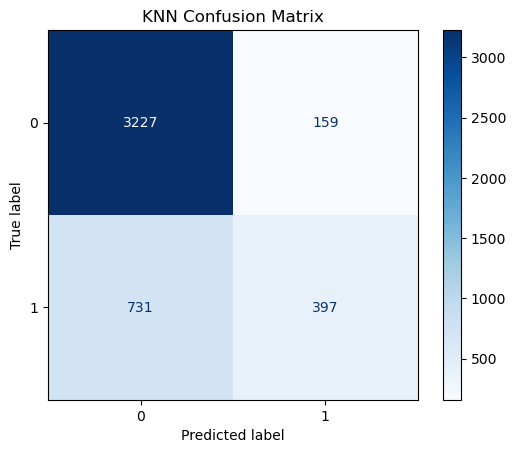

In [26]:
print(classification_report(y_test, y_pred))


#Compute the confusion matrix using actual and predicted values
cm = confusion_matrix(y_test, y_pred)
# Print the confusion matrix
print("Confusion Matrix",cm)
# Create a visualization of the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# Plot the confusion matrix with a blue color map for better visualization
disp.plot(cmap=plt.cm.Blues)
# Add a title to the plot
plt.title('KNN Confusion Matrix')
plt.show()

## Decision Tree Model 
 A Decision Tree is a tree-like model that makes decisions based on feature values. It recursively splits the dataset based on the best feature that reduces uncertainty. It is easy to interpret and works well for both classification and regression tasks.

In [28]:
#Initialaize
model = DecisionTreeClassifier()
#Fit the model on the training data
model.fit(X_train, y_train)

# Predict the labels for the test data (X_test: test features)
y_pred = model.predict(X_test)


# Calculate the accuracy by comparing the true labels (y_test) with the predicted labels (y_pred)
accuracy=metrics.accuracy_score(y_test, y_pred)


print("Accuracy:", accuracy)



Accuracy: 0.7620735489587949


## Output of DT Model
The Decision Tree model achieved an accuracy of 0.762, meaning it correctly predicted the class for approximately 76.2% of the test instances. The comparison between the actual and predicted values reveals mostly correct predictions, but there is one incorrect prediction, where the model predicted class 1 instead of 0, indicating a false positive.

In [29]:
#results of predicted and actual values
results = pd.DataFrame({ 'Actual': y_test, 'Predicted': y_pred})

# Print the first few rows of the results
print(results.head())

       Actual  Predicted
30181       0          0
24998       0          0
26084       0          0
34151       0          0
45189       1          0


## DT Evaluation 
The Decision Tree model shows an accuracy of 76%, with strong performance in predicting class 0 (precision of 0.81 and recall of 0.89). However, it struggles with class 1, achieving low precision (0.53) and recall (0.37), leading to many false negatives. The confusion matrix confirms this, with 706 false negatives and 368 false positives for class 1

              precision    recall  f1-score   support

           0       0.81      0.89      0.85      3386
           1       0.53      0.37      0.44      1128

    accuracy                           0.76      4514
   macro avg       0.67      0.63      0.64      4514
weighted avg       0.74      0.76      0.75      4514

Confusion Matrix [[3018  368]
 [ 706  422]]


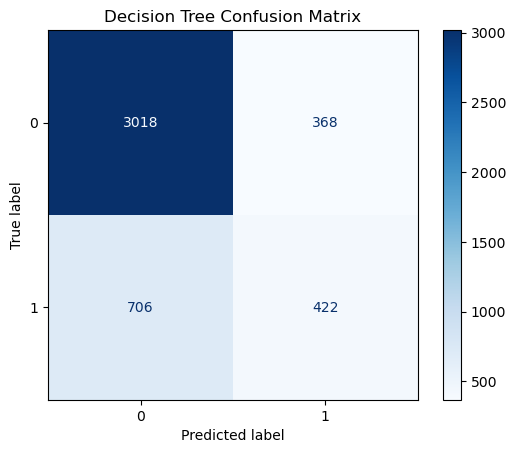

In [30]:
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix", cm)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.show()

## Naïve Bayes
Naive Bayes is a probabilistic classifier based on Bayes' theorem, assuming independence between features. It is particularly useful for large datasets and text classification tasks, where features are often conditionally independent.

In [31]:

model = GaussianNB()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy=metrics.accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7567567567567568


## Naïve Bayes Output 
It predicted mostly correct for class 0. However, in fifth row it predicted class 1 instances as class zero, indicating that the model struggles with accurately identifying class 1.

In [32]:
#results of predicted and actual values
results = pd.DataFrame({ 'Actual': y_test, 'Predicted': y_pred})

# Print the first few rows of the results
print(results.head())

       Actual  Predicted
30181       0          0
24998       0          0
26084       0          0
34151       0          0
45189       1          0


## Naïve Bayes Evaluation 
It achieved an accuracy of 76%, with strong performance for class 0, achieving a precision of 0.77 and recall of 0.96, indicating the model correctly identified most class 0 instances. However, for class 1, precision dropped to 0.55, and recall was very low at 0.15, meaning the model missed many class 1 instances, leading to false negatives. The confusion matrix confirms this, with 959 false negatives and 139 false positives for class 1.

              precision    recall  f1-score   support

           0       0.77      0.96      0.86      3386
           1       0.55      0.15      0.24      1128

    accuracy                           0.76      4514
   macro avg       0.66      0.55      0.55      4514
weighted avg       0.72      0.76      0.70      4514

Confusion Matrix [[3247  139]
 [ 959  169]]


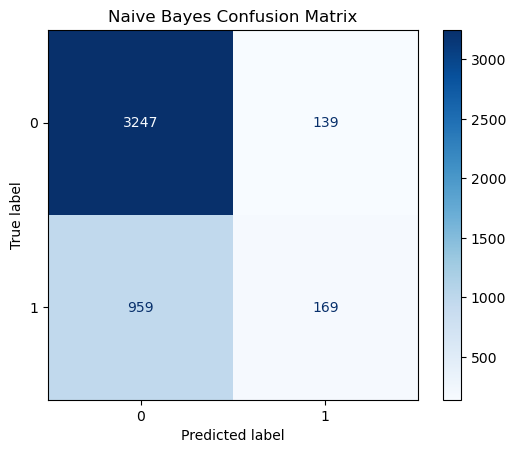

In [33]:
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix", cm)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Naive Bayes Confusion Matrix')
plt.show()

## Random Forest Model
Random Forest is an ensemble method that combines multiple Decision Trees to improve prediction accuracy.

In [32]:
# Create a RandomForestClassifier instance with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=999, class_weight='balanced')

# Fit the model on the training data
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# Print the accuracy score
accuracy=metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7702702702702703


## Output of RF 
The Random Forest model correctly predicted class 0 in the first few rows, as the actual and predicted values matched. However, it misclassified a class 1 instance as class 0 in the fifth row, indicating a false negative. While the model performs well in predicting class 0, it struggles with accurately identifying class 1, which may lead to an imbalance in performance between the two classes. 

In [28]:

results = pd.DataFrame({'Actual': y_test,'Predicted': y_pred})

# Print the first few rows of the results
print(results.head())

       Actual  Predicted
30181       0          0
24998       0          0
26084       0          0
34151       0          0
45189       1          0


## RF Evaluation
It achieved an accuracy of approximately 77%. For class 0, the model performs well with a precision of 0.77 and a high recall of 0.99, correctly identifying most instances of class 0. However, it struggles with class 1, where the precision is 0.76, but the recall drops significantly to 0.13, meaning the model misses many class 1 instances (false negatives). The F1-score for class 1 is low at 0.22, reflecting this imbalance. The average recall and F1-score (0.56 and 0.54) highlight the model's challenges with class 1. 

In [29]:
# Print the classification report (precision, recall, f1-score)
print(classification_report(y_test, y_pred))



cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix", cm)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Random Forest Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           0       0.77      0.99      0.87      3386
           1       0.76      0.13      0.22      1128

    accuracy                           0.77      4514
   macro avg       0.77      0.56      0.54      4514
weighted avg       0.77      0.77      0.71      4514

Accuracy: 0.7724856003544528


# Conclusion

In this project, we explored the Adult dataset to predict income categories, focusing on data preprocessing, exploratory analysis, and implementing multiple machine learning algorithms: K-Nearest Neighbors (KNN), Decision Tree (DT), Naive Bayes (NB), and Random Forest (RF). Preprocessing steps addressed missing values and prepared the data for analysis, while visualizations highlighted relationships between demographic factors and income levels. The KNN model achieved the highest accuracy (80%). The Decision Tree and Naive Bayes models, despite lower accuracy, performed better in certain aspects like precision for class 0, while the Random Forest model exhibited a good balance between precision and recall for both classes. Challenges included handling imbalanced data and tuning the models to prevent overfitting. This project demonstrated the potential of machine learning for deriving actionable insights, with opportunities for future improvement using advanced algorithms, hyperparameter tuning, and additional feature engineering.










# REFERENCES
[1]Becker, B. &**bold text** Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.n
22922385
[2]https://www.geeksforgeeks.org/k-nearest-neighbours/
